<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3813 acc 0.417 | val loss 1.3589 acc 0.456 *


[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.3304 acc 0.437 | val loss 1.1670 acc 0.432 *


[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.2145 acc 0.483 | val loss 1.0395 acc 0.556 *


[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.1763 acc 0.556 | val loss 1.0170 acc 0.607 *


...

[ResNet-50] Epoch  40/100 | LR: 2.68e-06 | train loss 0.2001 acc 0.892 | val loss 0.5101 acc 0.810


[ResNet-50] Epoch  41/100 | LR: 2.68e-06 | train loss 0.1826 acc 0.899 | val loss 0.4799 acc 0.815


[ResNet-50] Epoch  42/100 | LR: 2.68e-06 | train loss 0.1960 acc 0.890 | val loss 0.4865 acc 0.807


[ResNet-50] Epoch  43/100 | LR: 2.68e-06 | train loss 0.1868 acc 0.911 | val loss 0.4939 acc 0.805


[ResNet-50] Epoch  44/100 | LR: 2.68e-06 | train loss 0.1753 acc 0.902 | val loss 0.5276 acc 0.815

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 44.

[ResNet-50] Restored best checkpoint (val loss = 0.4644)


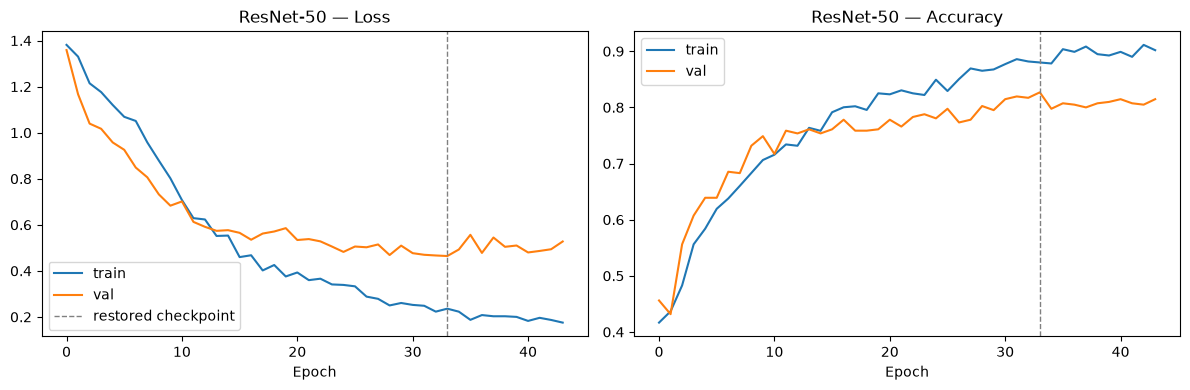

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.726


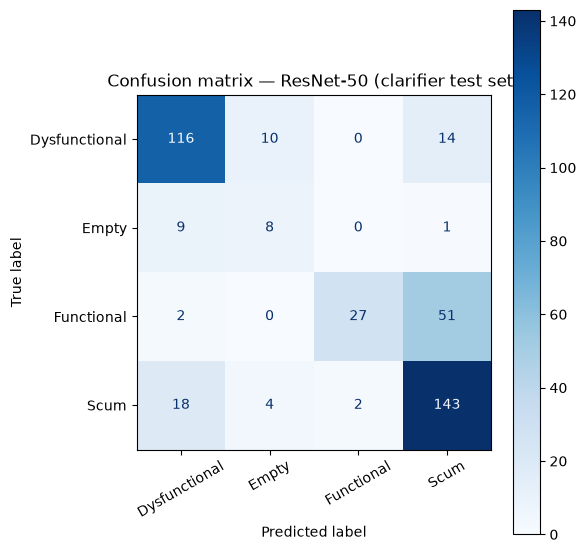

               precision    recall  f1-score   support

Dysfunctional      0.800     0.829     0.814       140
        Empty      0.364     0.444     0.400        18
   Functional      0.931     0.338     0.495        80
         Scum      0.684     0.856     0.761       167

     accuracy                          0.726       405
    macro avg      0.695     0.617     0.618       405
 weighted avg      0.759     0.726     0.711       405



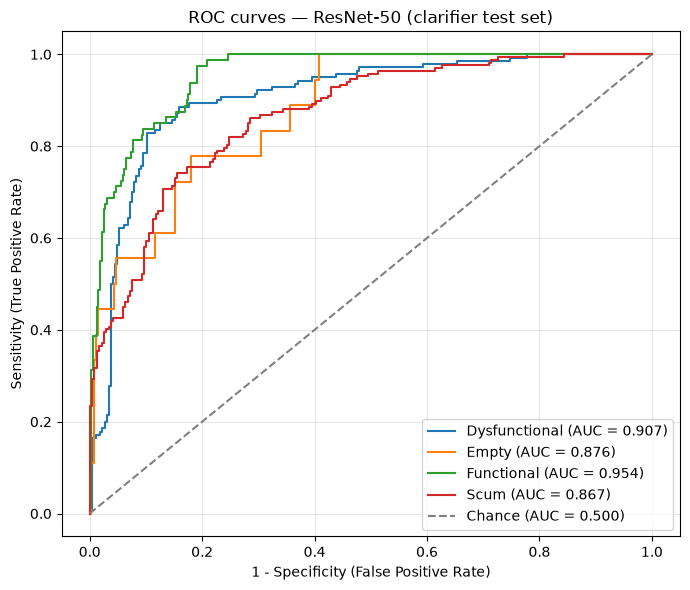

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.907
  Empty          : 0.876
  Functional     : 0.954
  Scum           : 0.867

Mean AUC (over 4/4 classes with test examples): 0.901


(np.float64(0.725925925925926),
 {'Dysfunctional': 0.9073584905660377,
  'Empty': 0.8763996554694229,
  'Functional': 0.9538846153846154,
  'Scum': 0.8670809641221758})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
